<a href="https://colab.research.google.com/github/cookmo/Cook_NEUR265/blob/main/coding_homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Morgan Cook
*NEUR265: Introduction to Neural Data Analysis*

**April 2, 2026**

In [1]:
# Importing modules (#2)
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Importing data (#3)
spikes_left_trial1 = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial1.csv', delimiter = ',')
spikes_left_trial2 = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial2.csv', delimiter = ',')
spikes_right_trial1 = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial1.csv', delimiter = ',')
spikes_right_trial2 = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial2.csv', delimiter = ',')

In [5]:
# Printing the lengths of the arrays (#4)
print(len(spikes_left_trial1))
print(len(spikes_left_trial2))
print(len(spikes_right_trial1))
print(len(spikes_right_trial2))

65
53
45
69


In [11]:
# Determining the firing rate of neuron (#6)
spikes_per_sec_left1 = len(spikes_left_trial1) / 30
print(spikes_per_sec_left1)

spikes_per_sec_left2 = len(spikes_left_trial2) / 30
print(spikes_per_sec_left2)

spikes_per_sec_right1 = len(spikes_right_trial1) / 30
print(spikes_per_sec_right1)

spikes_per_sec_right2 = len(spikes_right_trial2) / 30
print(spikes_per_sec_right2)

2.1666666666666665
1.7666666666666666
1.5
2.3


The spikes per second between the left and right trials are not drastically different, as they are mixed/varying in values. Due to this, it is difficult to tell whether the neuron fires more before left or right turn trials.

Text(0.5, 0, 'Time (s)')

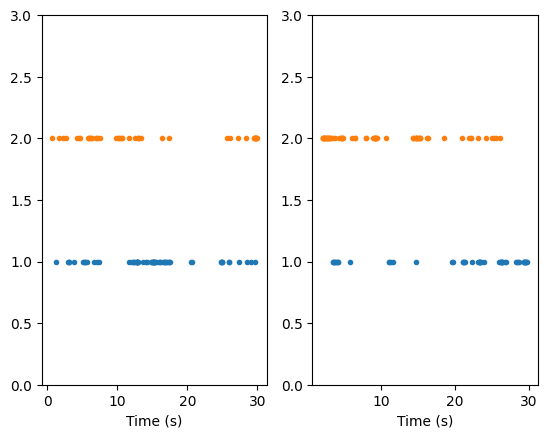

In [25]:
# Making subplots (#8)
fig, ax = plt.subplots(1, 2)

ax[0].plot(spikes_left_trial1, np.ones_like(spikes_left_trial1), '.')
ax[0].plot(spikes_right_trial1,  2 * np.ones_like(spikes_right_trial1), '.')

ax[1].plot(spikes_left_trial2, np.ones_like(spikes_left_trial2), '.')
ax[1].plot(spikes_right_trial2,  2 * np.ones_like(spikes_right_trial2), '.')

ax[0].set_ylim([0, 3])
ax[1].set_ylim([0, 3])

ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')

The neuron appears to be more bursty during right-turn trials. Both plots display less consistent/evenly distributed orange dots (representative of the right turn trials).

In [27]:
# Calculating ISI arrays (#10)
isi_left1 = np.diff(spikes_left_trial1)
isi_left2 = np.diff(spikes_left_trial2)
isi_right1 = np.diff(spikes_right_trial1)
isi_right2 = np.diff(spikes_right_trial2)

print(isi_left1)
print(isi_left2)
print(isi_right1)
print(isi_right2)

[1.75574  0.057416 0.044268 0.682444 1.233286 0.22358  0.06531  0.020767
 0.279245 1.098578 0.356628 0.259738 4.367309 0.45441  0.136212 0.041073
 0.250092 0.194642 0.013271 0.017694 0.039383 0.025559 0.039875 0.087183
 0.669328 0.444426 0.08617  0.658759 0.04267  0.010568 0.177039 0.049183
 0.042947 0.012103 0.027157 0.009953 0.033915 0.199219 0.080671 0.417423
 0.138916 0.056955 0.423076 0.139837 0.031519 0.032256 0.116337 0.190494
 0.304743 0.038922 0.025313 3.139308 0.007495 4.216013 0.005683 0.099533
 0.047585 0.011305 0.951061 0.031273 1.420155 1.117563 0.621803 0.521933]
[0.009524 0.060979 0.043161 0.056525 0.188928 0.150528 0.100332 0.024238
 1.628436 5.248512 0.013886 0.230523 0.308428 3.140967 4.812933 0.148531
 1.346704 0.068167 0.054098 0.03926  0.162386 0.900465 0.903475 0.129362
 0.010967 0.01195  0.044268 0.037232 0.048323 0.426332 2.021069 0.143431
 0.14079  0.055481 0.058368 0.016773 0.011765 0.014562 0.464978 0.038461
 1.453548 0.098672 0.105155 0.133079 0.663767 0.04

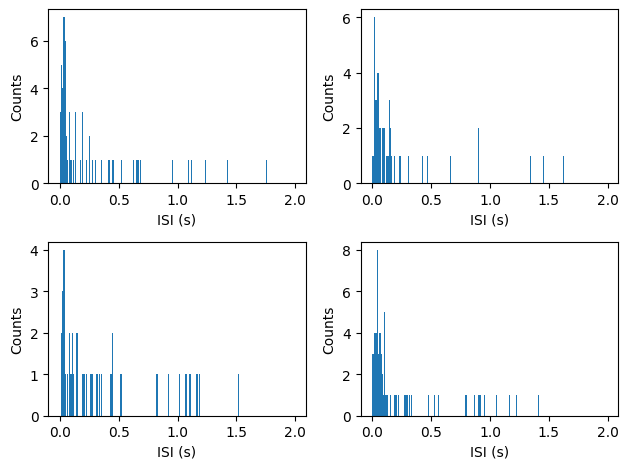

In [43]:
# Creating histograms for ISI arrays (#11)
fig, ax = plt.subplots(2, 2)
bins = np.arange(0, 2, 0.01)

ax[0,0].hist(isi_left1, bins)
ax[0,0].set_xlabel('ISI (s)')
ax[0,0].set_ylabel('Counts')

ax[0,1].hist(isi_left2, bins)
ax[0,1].set_xlabel('ISI (s)')
ax[0,1].set_ylabel('Counts')

ax[1,0].hist(isi_right1, bins)
ax[1,0].set_xlabel('ISI (s)')
ax[1,0].set_ylabel('Counts')

ax[1,1].hist(isi_right2, bins)
ax[1,1].set_xlabel('ISI (s)')
ax[1,1].set_ylabel('Counts')

plt.tight_layout()

The neuron does seem to fire in bursts, which we can see by the high frequency of spikes with a low ISI. The neuron seems to be more bursty during right turn trials, specifically displayed in the second trial (shown in the bottom right).

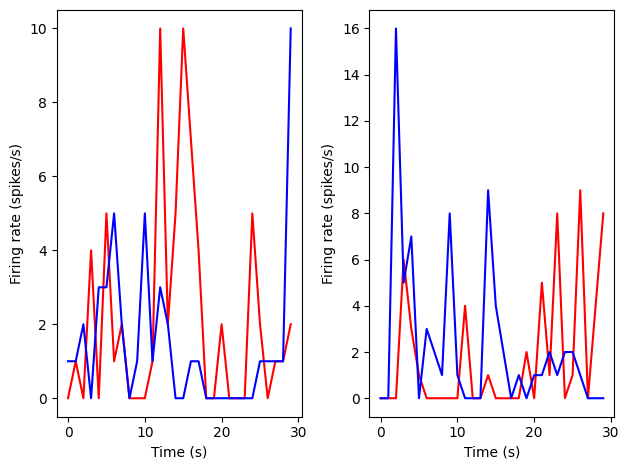

In [54]:
# Calculating the firing rates for each array
fig, ax = plt.subplots(1, 2)
bins = np.arange(0, 31, 1)

t1_left_count, edges = np.histogram(spikes_left_trial1, bins)
t2_left_count, edges = np.histogram(spikes_left_trial2, bins)
t1_right_count, edges = np.histogram(spikes_right_trial1, bins)
t2_right_count, edges = np.histogram(spikes_right_trial2, bins)

ax[0].plot(bins[:30], t1_left_count, color='red')
ax[0].plot(bins[:30], t1_right_count, color='blue')

ax[1].plot(bins[:30], t2_left_count, color='red')
ax[1].plot(bins[:30], t2_right_count, color='blue')

ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[0].set_ylabel('Firing rate (spikes/s)')
ax[1].set_ylabel('Firing rate (spikes/s)')

plt.tight_layout()

The firing rate between left and right turn trials differ during the 30s second. Trial 1 shows the highest firing rate during the left-turn trial around the 15 second mark, being greater overall than for the right turn trial except for at the very end. Trial 2 shows that the firing rate was greatest for the right turn trials up until the 15 second mark, but switched to the left turn trial afterwards.